# Project Overview & Dataset

## Problem Statement
The objective of this project is to develop a machine learning model capable of automatically categorizing IT support tickets across multiple languages.

## Dataset Description
This project uses the Multilingual Customer Support Tickets dataset.

# Project Setup

In [19]:
import kagglehub
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Download dataset

In [4]:
# Download latest version

DATA_FOLDER = "../data"

FILE_NAME = "aa_dataset-tickets-multi-lang-5-2-50-version.csv"

path = kagglehub.dataset_download("tobiasbueck/multilingual-customer-support-tickets")

print("Dataset downloaded to cache:", path)

if not os.path.exists(DATA_FOLDER):
    os.mkdir(DATA_FOLDER)
    print(f"Folder created: {DATA_FOLDER}")

src_path = os.path.join(path, FILE_NAME)
dest_path = os.path.join(DATA_FOLDER, FILE_NAME)

if not os.path.exists(dest_path):
    if os.path.exists(src_path):
        print(f"Copying '{FILE_NAME}' to the project folder...")
        shutil.copy(src_path, dest_path)
        print("Copy finished successfully.")
    else:
        print(f"File '{FILE_NAME}' not found in the downloaded files.")
else:
    print(f"File '{FILE_NAME}' already exists in {DATA_FOLDER}. Skipping copy.")

# Verification
print(f"Files in {DATA_FOLDER}: {os.listdir(DATA_FOLDER)}")

Dataset downloaded to cache: /home/jano/.cache/kagglehub/datasets/tobiasbueck/multilingual-customer-support-tickets/versions/14
File 'aa_dataset-tickets-multi-lang-5-2-50-version.csv' already exists in ../data. Skipping copy.
Files in ../data: ['aa_dataset-tickets-multi-lang-5-2-50-version.csv']


# Load and Exploratory Data Analysis

## Basic Dataset Inspection

In [5]:
df_original = pd.read_csv(dest_path)

# basic info
print("Dataset info:")
print(df_original.info())
print("#"*50)
print("\nFirst 5 rows:")
display(df_original.head(5))
print("\nDataset shape:")
print(df_original.shape)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   subject   24749 non-null  str  
 1   body      28587 non-null  str  
 2   answer    28580 non-null  str  
 3   type      28587 non-null  str  
 4   queue     28587 non-null  str  
 5   priority  28587 non-null  str  
 6   language  28587 non-null  str  
 7   version   28587 non-null  int64
 8   tag_1     28587 non-null  str  
 9   tag_2     28574 non-null  str  
 10  tag_3     28451 non-null  str  
 11  tag_4     25529 non-null  str  
 12  tag_5     14545 non-null  str  
 13  tag_6     5874 non-null   str  
 14  tag_7     2040 non-null   str  
 15  tag_8     565 non-null    str  
dtypes: int64(1), str(15)
memory usage: 3.5 MB
None
##################################################

First 5 rows:


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN



Dataset shape:
(28587, 16)


## Distribution of Objective Variables

In [ ]:
print("--- Queue Distribution in percentage ---")
display((df_original["queue"].value_counts(normalize=True)*100).round(2))

print("\n--- Priority Distribution in percentage ---")
display((df_original["priority"].value_counts(normalize=True)*100).round(2))

--- Queue Distribution in percentage ---


queue
Technical Support                  29.25
Product Support                    18.37
Customer Service                   14.93
IT Support                         12.01
Billing and Payments                9.75
Returns and Exchanges               5.03
Service Outages and Maintenance     4.02
Sales and Pre-Sales                 3.21
Human Resources                     2.01
General Inquiry                     1.42
Name: proportion, dtype: float64


--- Priority Distribution in percentage ---
priority
medium    40.28
high      39.10
low       20.62
Name: proportion, dtype: float64


## Missing Data Detection

Text representation:

body            0
type            0
priority        0
queue           0
language        0
version         0
tag_1           0
answer          7
tag_2          13
tag_3         136
tag_4        3058
subject      3838
tag_5       14042
tag_6       22713
tag_7       26547
tag_8       28022
dtype: int64

Graphic representation


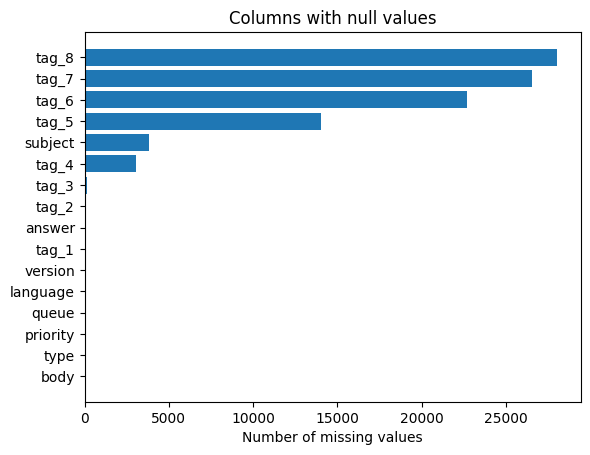

In [7]:
null_sum = df_original.isnull().sum()
null_sum = null_sum.sort_values(ascending=True)
print("Text representation:\n")
print(null_sum)

print("\nGraphic representation")
plt.barh(null_sum.index,null_sum.values)
plt.title("Columns with null values")
plt.xlabel('Number of missing values')
plt.show()

## Objective Variable Distribution

### Queue Distribution

Text representation:

queue
Technical Support                  8362
Product Support                    5252
Customer Service                   4268
IT Support                         3433
Billing and Payments               2788
Returns and Exchanges              1437
Service Outages and Maintenance    1148
Sales and Pre-Sales                 918
Human Resources                     576
General Inquiry                     405
Name: count, dtype: int64

Graphic representation


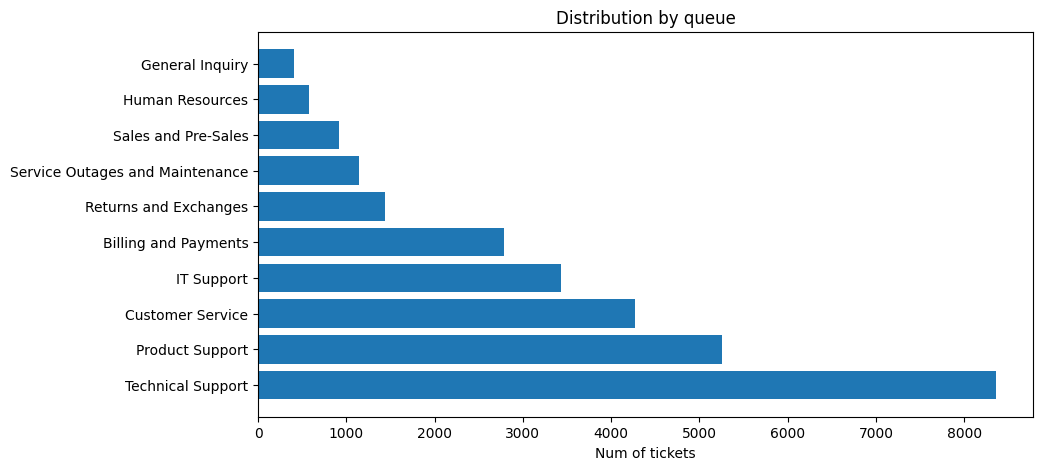

In [8]:
queue_tickets = df_original["queue"].value_counts()
print("Text representation:\n")
print(queue_tickets)

print("\nGraphic representation")
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(queue_tickets.index,queue_tickets.values)
ax.set_title("Distribution by queue")
ax.set_xlabel("Num of tickets")
plt.show()

### Priority Distribution

Text representation:

priority
medium    11515
high      11178
low        5894
Name: count, dtype: int64

Graphic representation


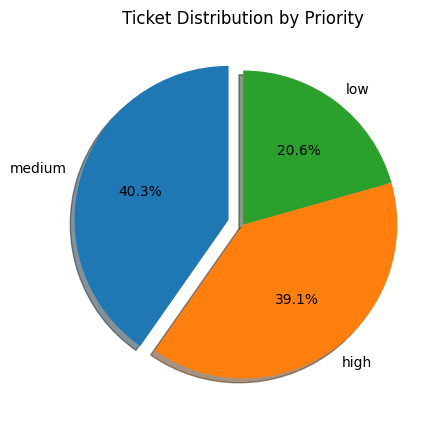

In [9]:
priority_tickets = df_original["priority"].value_counts()
print("Text representation:\n")
print(priority_tickets)

print("\nGraphic representation")
fig, ax = plt.subplots(figsize=(10, 5))
explode = (0.1, 0, 0)
ax.pie(priority_tickets.values, labels=priority_tickets.index, explode=explode, 
        shadow=True, autopct='%1.1f%%', startangle=90)

plt.title("Ticket Distribution by Priority")
plt.show()

## Type Distribution by Queue

type,Change,Incident,Problem,Request
queue,,,,
Billing and Payments,159,674,615,1340
Customer Service,321,1074,904,1969
General Inquiry,120,117,77,91
Human Resources,30,316,57,173
IT Support,584,1244,870,735
Product Support,601,2306,1149,1196
Returns and Exchanges,188,568,290,391
Sales and Pre-Sales,154,203,119,442
Service Outages and Maintenance,273,630,79,166


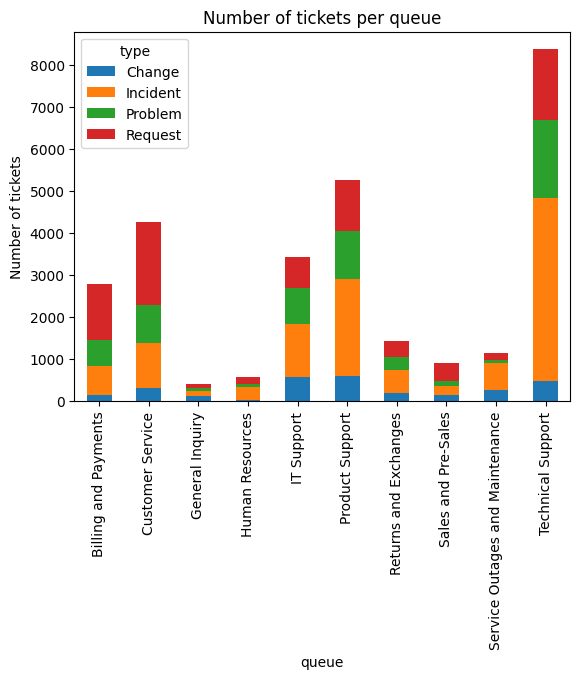

In [10]:
result = df_original.groupby(['queue', 'type']).size().unstack(fill_value=0)
display(result)

result.plot(kind='bar', stacked=True)
plt.title("Number of tickets per queue")
plt.ylabel("Number of tickets")
plt.show()

## Language Distribution

Text representation:

language
en    16338
de    12249
Name: count, dtype: int64

Graphic representation


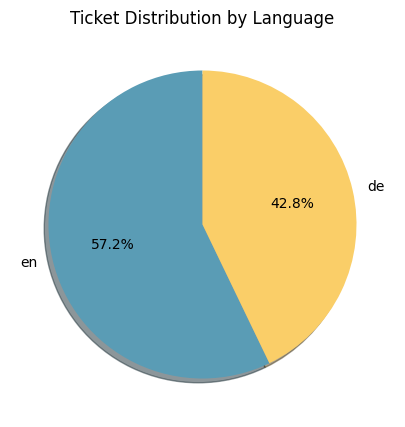

In [11]:
tickets_per_language = df_original["language"].value_counts()

print("Text representation:\n")
print(tickets_per_language)

print("\nGraphic representation")

custom_colors = ["#5A9CB5", "#FACE68"]

fig, ax = plt.subplots(figsize=(10, 5))

ax.pie(tickets_per_language.values, labels=tickets_per_language.index, 
       autopct='%1.1f%%', startangle=90, shadow=True, colors=custom_colors)

plt.title("Ticket Distribution by Language")
plt.show()

## Text Length

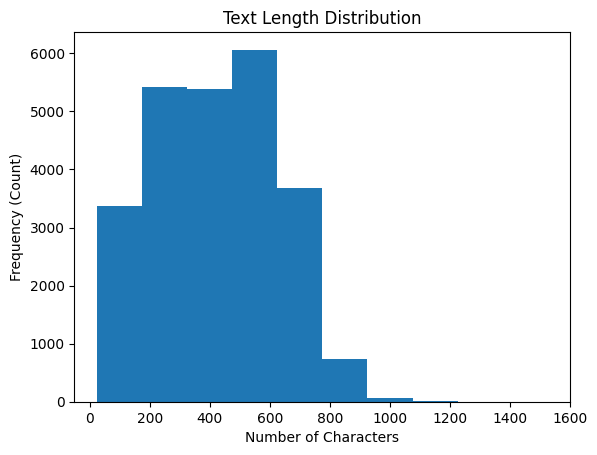

In [12]:
full_text = df_original["subject"] + ". " + df_original["body"]

fig, ax = plt.subplots()
ax.hist(full_text.str.len())
ax.set_title("Text Length Distribution")
ax.set_xlabel("Number of Characters")
ax.set_ylabel("Frequency (Count)")
plt.show()

# Data Preprocessing

In [13]:
df = df_original[["subject", "body", "queue", "priority"]].copy()

display(df.info())

display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   subject   24749 non-null  str  
 1   body      28587 non-null  str  
 2   queue     28587 non-null  str  
 3   priority  28587 non-null  str  
dtypes: str(4)
memory usage: 893.5 KB


None

,subject,body,queue,priority
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Technical Support,high
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Technical Support,high
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Returns and Exchanges,medium
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Billing and Payments,low
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Sales and Pre-Sales,medium


In [14]:
# Fill null values in the subject column
df["subject"] = df["subject"].fillna("")


df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   subject   28587 non-null  str  
 1   body      28587 non-null  str  
 2   queue     28587 non-null  str  
 3   priority  28587 non-null  str  
dtypes: str(4)
memory usage: 893.5 KB


In [ ]:
# Concatenate 'subject' and 'body' to provide the model with the full context of the ticket
df["full_text"] = df["subject"] + ". " + df["body"]

rng = np.random.default_rng()

rand_num = rng.integers(0, len(df))

df["full_text"].iloc[rand_num]

'Probleme mit Updates bei digitalen Kampagnen. Das Unternehmen hat mehrere Produktfehler festgestellt, die digitale Kampagnen stören. Diese Störungen könnten auf kürzliche Software-Updates zurückzuführen sein. Die Fehlerbehebung umfasste die Neuinstallation von Adobe Photoshop sowie das Zurücksetzen von Cisco Webex, jedoch ohne Erfolg. Wir benötigen Unterstützung, um das Problem so schnell wie möglich zu lösen und die Auswirkungen auf die Abläufe zu minimieren.'